The model is clathrin + clathrin <-> clathrin.clathrin. It will form flat lattice and the maximum size is unlimited. The copy numbers of clathrin is 100. It will compare numbers of bonds from the simulation and theory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ioNERDSS as io

kD = 1uM; koff = 1s-1

In [2]:
df = pd.read_csv('./kon1uM/copy_numbers_time.dat')
df

,Time (s),clat(cd1),clat(cd2),clat(cd3),clat(td1),clat(td2),clat(td3),clat(ref),clat(cd1!1).clat(cd1!1),clat(cd2!1).clat(cd2!1),clat(cd3!1).clat(cd3!1),clat(cd1!1).clat(cd2!1),clat(cd1!1).clat(cd3!1),clat(cd2!1).clat(cd3!1),clat(ref!1).clat(ref!1)
0,0.000,100,100,100,100,100,100,100,0,0,0,0,0,0,0
1,0.001,98,96,98,100,100,100,100,1,1,0,0,0,2,0
2,0.002,97,96,95,100,100,100,100,1,1,1,0,1,2,0
3,0.003,97,96,95,100,100,100,100,1,1,1,0,1,2,0
4,0.004,97,96,95,100,100,100,100,1,1,1,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,9.996,27,40,35,100,100,100,100,16,9,16,25,16,17,0
9997,9.997,27,40,35,100,100,100,100,16,9,16,25,16,17,0
9998,9.998,27,40,35,100,100,100,100,16,9,16,25,16,17,0
9999,9.999,27,40,35,100,100,100,100,16,9,16,25,16,17,0


In [3]:
bonds = df['clat(cd1!1).clat(cd1!1)'] + df['clat(cd2!1).clat(cd2!1)'] + df['clat(cd3!1).clat(cd3!1)'] + df['clat(cd1!1).clat(cd2!1)'] + df['clat(cd1!1).clat(cd3!1)'] + df['clat(cd2!1).clat(cd3!1)']
bonds 

0         0
1         4
2         6
3         6
4         6
         ..
9996     99
9997     99
9998     99
9999     99
10000    99
Length: 10001, dtype: int64

In [4]:
time = df['Time (s)']
time

0         0.000
1         0.001
2         0.002
3         0.003
4         0.004
          ...  
9996      9.996
9997      9.997
9998      9.998
9999      9.999
10000    10.000
Name: Time (s), Length: 10001, dtype: float64

In [6]:
# Theoretical Solution for reversible self binding
def reversible_self_theo_solu(koff, kon, A0, time, volume):
    q0 = koff*A0
    q1 = - koff
    q2 = - kon * 2
    r1 = (q1+np.sqrt(q1**2-4*q0*q2))/2
    r2 = (q1-np.sqrt(q1**2-4*q0*q2))/2
    lam = (r2+A0*q2)/(r1+A0*q2)
    At = 1 / q2*(lam*r1*np.exp(r1*time)-r2*np.exp(r2*time))/(np.exp(r2*time)-lam*np.exp(r1*time))
    At_copies = At * volume * 602.3
    return At_copies


In [9]:
koff = 1  # s-1
kon = 1  # uM-1s-1
nA0 = 300 # copy number
volume = 0.494**3  # um^3
A0 = nA0 / volume / 602.3  # uM
bonds_theory = (nA0 - reversible_self_theo_solu(koff, kon, A0, time, volume)) / 2  

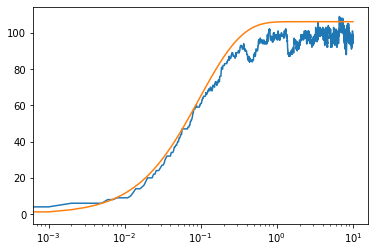

In [11]:
plt.semilogx(time,bonds)
plt.semilogx(time,bonds_theory)
plt.show()

kD = 0.2uM

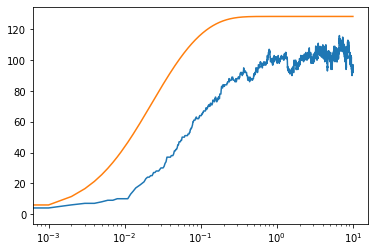

In [15]:
df02uM = pd.read_csv('./kon02uM/copy_numbers_time.dat')
bonds02uM = df02uM['clat(cd1!1).clat(cd1!1)'] + df['clat(cd2!1).clat(cd2!1)'] + df['clat(cd3!1).clat(cd3!1)'] + df['clat(cd1!1).clat(cd2!1)'] + df['clat(cd1!1).clat(cd3!1)'] + df['clat(cd2!1).clat(cd3!1)']
time02uM = df02uM['Time (s)']
koff = 1  # s-1
kon = 5  # uM-1s-1
nA0 = 300 # copy number
volume = 0.494**3  # um^3
A0 = nA0 / volume / 602.3  # uM
bonds02uM_theory = (nA0 - reversible_self_theo_solu(koff, kon, A0, time, volume)) / 2  
plt.semilogx(time02uM,bonds02uM)
plt.semilogx(time02uM,bonds02uM_theory)
plt.show()

kD = 100uM

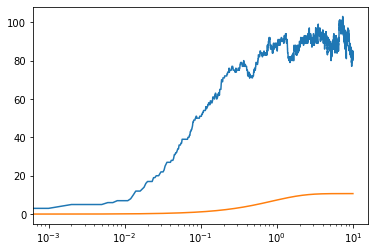

In [16]:
df100uM = pd.read_csv('./kon100uM/copy_numbers_time.dat')
bonds100uM = df100uM['clat(cd1!1).clat(cd1!1)'] + df['clat(cd2!1).clat(cd2!1)'] + df['clat(cd3!1).clat(cd3!1)'] + df['clat(cd1!1).clat(cd2!1)'] + df['clat(cd1!1).clat(cd3!1)'] + df['clat(cd2!1).clat(cd3!1)']
time100uM = df100uM['Time (s)']
koff = 1  # s-1
kon = 0.01  # uM-1s-1
nA0 = 300 # copy number
volume = 0.494**3  # um^3
A0 = nA0 / volume / 602.3  # uM
bonds100uM_theory = (nA0 - reversible_self_theo_solu(koff, kon, A0, time, volume)) / 2  
plt.semilogx(time100uM,bonds100uM)
plt.semilogx(time100uM,bonds100uM_theory)
plt.show()